This file illustrates how to train (finetune) a superresolution model to give outcome image easy to compress by Neural Image Compression 

The model 
```
     superresolutoin
x -> fsr(x) -> X -> h(X) -> Y -> Bitstream -> Y^ -> g(Y^) -> X^
                            |                 ^
                            v                 |
                           h(Y)             g(Z^)
                            |                 ^
                            v                 |
                            Z -> Hyperprior -> Z^
 
```

•  x represents the input image.

•  X = fsr(x\Theta) : superresolution image model 

•  h(x) is the analysis transform that converts x into a latent representation, followed by quantization.

•  y is the quantized latent representation that is entropy coded into a bitstream.

•  The hyperprior is used to model the probability distribution of y for efficient entropy coding.

•  y^ is the quantized latent representation obtained after entropy decoding the bitstream.

•  g(y^) is the synthesis transform that reconstructs the output image x^ from y^.

•  x^ is the final output image reconstructed by the synthesis transform.


The main task is to finetune fsr() with the following condiitons  
 -  the bitrate of (Y,Z) is Minimized

 - difference between X^ and X^_0 is minimum (the image compressed by the original fsr)


 Anh-Huy Phan 2024

In [1]:
import math
import torch
# from torchsr.datasets import      
from torchsr.models import ninasr_b0
from torchvision.transforms.functional import to_pil_image, to_tensor

In [2]:
# import torch
# import os
# import subprocess


# def get_gpu_memory_usage():
#     """
#     Gets the memory usage of all available GPUs using `nvidia-smi`.
#     Returns a list of tuples [(gpu_id, used_memory), ...].
#     """
#     try:
#         # Run nvidia-smi to get memory usage
#         result = subprocess.check_output(
#             ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
#             encoding="utf-8"
#         )
#         memory_usage = result.strip().split("\n")
#         memory_usage = [(i, int(mem)) for i, mem in enumerate(memory_usage)]
#         return memory_usage
#     except Exception as e:
#         print(f"Error getting GPU memory usage: {e}")
#         return []


# def select_gpu():
#     """
#     Selects the GPU with the least memory utilization.
#     Returns the GPU ID of the selected GPU.
#     """
#     memory_usage = get_gpu_memory_usage()
#     if not memory_usage:
#         print("No GPUs detected or error reading GPU info.")
#         return None

#     # Select GPU with the least memory usage
#     selected_gpu = min(memory_usage, key=lambda x: x[1])[0]
#     print(f"Selected GPU: {selected_gpu} with memory usage: {memory_usage[selected_gpu][1]} MB")
#     return selected_gpu
# device = select_gpu()

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [4]:
# Download a pretrained NinaSR model for super 
model = ninasr_b0(scale=2, pretrained=True)
model = model.to(device)

In [5]:
# # Load AI compression model

# import importlib.util

# package_name = 'compressai'

# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install compressai    

# package_name = 'skimage'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install scikit-image    

# package_name = 'kornia'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install kornia    
# # !pip install piq     

In [6]:

from torchvision import transforms
import numpy as np

from PIL import Image 
  
import matplotlib.pyplot as plt
import torch.nn.functional as F



In [7]:
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor


import random

# Parameters
img_path = "E:/Share/Div2K/DIV2K_train_HR/0025.png"
crop_size = 512  # Size of the cropped window
scaled_size = 256  # Size of the scaled-down version

# Load the original high-resolution image
img = Image.open(img_path).convert('RGB')
width, height = img.size
 

# Randomly crop a 512x512 window from the original image
if width >= crop_size and height >= crop_size:
    left = random.randint(0, width - crop_size)
    top = random.randint(0, height - crop_size)
    right = left + crop_size
    bottom = top + crop_size
    cropped_img = img.crop((left, top, right, bottom))
else:
    raise ValueError("Image dimensions must be at least 512x512.")

# Use the cropped image as ground truth reference
ground_truth = cropped_img

# Resize the cropped image to 256x256 for low-resolution input
low_res_img = cropped_img.resize((scaled_size, scaled_size), Image.BICUBIC)

# Preprocessing transformations
preprocess = transforms.Compose([transforms.ToTensor()])

# Transform to tensor
input_tensor = preprocess(low_res_img).unsqueeze(0).to(device)
ground_truth_tensor = preprocess(ground_truth).unsqueeze(0).to(device)

# Print shapes for verification
print(f"Low-resolution input tensor shape: {input_tensor.shape}")
print(f"Ground truth tensor shape: {input_tensor.shape}")
  


Low-resolution input tensor shape: torch.Size([1, 3, 256, 256])
Ground truth tensor shape: torch.Size([1, 3, 256, 256])


In [8]:
# Extract the filename
import os
filename = os.path.basename(img_path)
print(filename[:-4])

0025


In [9]:
# sr = to_pil_image(input_tensor.clamp(0,1).squeeze(0))
# sr.show()

In [10]:
# FOR AI COMPRession
# Load Library for AI attack and defense 
import sys
import os

# Specify the directory containing libfunc.py
lib_path = "C:/Users/huyph"

# Add the directory to Python's module search path
if lib_path not in sys.path:
    sys.path.append(lib_path)

import aiimagcomp_atk_lib
import importlib    

importlib.reload(aiimagcomp_atk_lib)

from aiimagcomp_atk_lib import *


In [11]:
# Model name
model_name = "cheng2020-anchor" #'cheng2020-attn' 'cheng2020-anchor' 'mbt2018' 'mbt2018-mean'  'bmshj2018-hyperprior'  'bmshj2018_factorized_relu' 'bmshj2018_factorized'

# Quality
quality = 6
model_name2 = model_name.replace('-', '_')

## Load pretrained AI image compression models
# from compressai.zoo import cheng2020_anchor
from compressai.zoo import models

# Dynamically retrieve the model class
# model_class = models['cheng2020-anchor']
model_class = models[model_name]

# Clear GPU memory
torch.cuda.empty_cache()
# Set compression-decompression quality for AI image compression 
model_compression = model_class(quality=quality, pretrained=True).to(device)
for param in model_compression.parameters():
    param.requires_grad = False


# # model_forcompression (CPU)
# net = model_class(quality=quality, pretrained=True,progress=False).eval()


In [12]:
# Check the current memory usage on GPU
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Memory allocated: 115.05 MB
Memory cached: 138.00 MB


In [13]:
import gc
for obj in gc.get_objects():
    if isinstance(obj, torch.Tensor) and obj.is_cuda:
        print(f"GPU Tensor: {obj.size()}, {obj.device}, Memory: {obj.element_size() * obj.nelement() / 1024**2:.2f} MB")


GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([192]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([192, 92]), cuda:0, Memory: 0.07 MB
GPU Tensor: torch.Size([192]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([3]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0,

In [14]:
for obj in gc.get_objects():
    if isinstance(obj, torch.Tensor) and obj.is_cuda:
        print(f"GPU Tensor: {obj.size()}, {obj.device}, Memory: {obj.element_size() * obj.nelement() / 1024**2:.2f} MB")


GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([192]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([192, 92]), cuda:0, Memory: 0.07 MB
GPU Tensor: torch.Size([192]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([3]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0, Memory: 0.00 MB
GPU Tensor: torch.Size([1]), cuda:0,

In [15]:
torch.cuda.empty_cache()


In [16]:
def eval_perf_compression(model_compression,sr_image_tensor, ref_image_tensor= None):
    # Anh-Huy Phan 2024
    #
    # Forward pass through the compression model
    output_compression = model_compression(sr_image_tensor)

    # Assuming 'output' is a dictionary with key 'x_hat' for the reconstructed image
    # output_final = output_compression['x_hat']


    # Check the bitrate of compressed file for the superresolution image : sr_image_tensor
    # Compress the super resolution image 
    MAX_I = 1

    num_pixels = sr_image_tensor.shape[2]*sr_image_tensor.shape[3]
    # model and net are the same , but net is on cpu and for compression 

    mse_loss_original = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)
    target_psnr = 10 * torch.log10((MAX_I ** 2) / mse_loss_original)

    # Compute bpp loss (to be maximized, hence the negative sign)
    baseline_bpp = (torch.log(output_compression['likelihoods']['y']).sum() + \
        torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)

    target_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)


    compressfile = os.path.splitext(img_path)[0] + 'compress'
    bitdepth = 8
    h, w = sr_image_tensor.size(2), sr_image_tensor.size(3)

    with torch.no_grad():
        sr_output = model_compression.compress(sr_image_tensor)
        # sr_output = net.compress(sr_image_tensor.to('cpu'))


    baseline_true_bpp = savecompressed(compressfile,sr_output, bitdepth,h,w)


    if ref_image_tensor is not None:
        vs_ref_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        mse_ref = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        vs_ref_psnr = 10 * torch.log10((MAX_I ** 2) / mse_ref)
    
        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp' : baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': vs_ref_psnr.cpu().detach().numpy(),'SSI_cmpref': vs_ref_ssim.cpu().detach().numpy()}
        
    else:
        vs_ref_ssim = None
        vs_ref_psnr = None

    
        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp' : baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': None,'SSI_cmpref': None}
    return sr_compression_result

In [17]:
# # Load entire model
# model = torch.load("sr_model_finetune_compression.pth")

In [18]:
# Generate superresolution from input_tensor
with torch.no_grad():
    sr_image_tensor = model(input_tensor)

sr_compression_result = eval_perf_compression(model_compression,sr_image_tensor,ground_truth_tensor)
print(sr_compression_result)

 

C:\Users\huyph\AppData\Local\Temp\ipykernel_34228\140740725.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(39.275192, dtype=float32), 'Bpp': array(0.49879596, dtype=float32), 'Bpp(fsize)': 0.390167236328125, 'SSIM': array(0.02182574, dtype=float32), 'PSNR_cmpref': array(32.518444, dtype=float32), 'SSI_cmpref': array(0.05938219, dtype=float32)}


In [19]:
sr_compression_result

{'PSNR': array(39.275192, dtype=float32),
 'Bpp': array(0.49879596, dtype=float32),
 'Bpp(fsize)': 0.390167236328125,
 'SSIM': array(0.02182574, dtype=float32),
 'PSNR_cmpref': array(32.518444, dtype=float32),
 'SSI_cmpref': array(0.05938219, dtype=float32)}

In [20]:
# import torch
import torchvision.transforms as transforms
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode
 
# Example Usage:
from PIL import Image


interpolation_methods = [InterpolationMode.NEAREST,InterpolationMode.BILINEAR,InterpolationMode.BICUBIC]
target_size = [ground_truth_tensor.shape[2],ground_truth_tensor.shape[3]]
# Store Results
baseline_sr_results = []

# Loop through interpolation methods
for method in interpolation_methods:
    resized_image = resize(input_tensor, target_size, interpolation=method)
    
    # Evaluate performance with the resized image
    sr_compression_result_interp = eval_perf_compression(model_compression, resized_image, ground_truth_tensor)
    
    # Append result to the list
    baseline_sr_results.append(sr_compression_result_interp)

baseline_sr_results

C:\Users\huyph\AppData\Local\Temp\ipykernel_34228\140740725.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)
c:\Users\huyph\anaconda3\envs\py38\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


[{'PSNR': array(38.841503, dtype=float32),
  'Bpp': array(0.5018042, dtype=float32),
  'Bpp(fsize)': 0.389801025390625,
  'SSIM': array(0.02608708, dtype=float32),
  'PSNR_cmpref': array(32.679043, dtype=float32),
  'SSI_cmpref': array(0.06514161, dtype=float32)},
 {'PSNR': array(42.378624, dtype=float32),
  'Bpp': array(0.35375002, dtype=float32),
  'Bpp(fsize)': 0.241973876953125,
  'SSIM': array(0.01148257, dtype=float32),
  'PSNR_cmpref': array(32.986065, dtype=float32),
  'SSI_cmpref': array(0.07092371, dtype=float32)},
 {'PSNR': array(40.681046, dtype=float32),
  'Bpp': array(0.40688303, dtype=float32),
  'Bpp(fsize)': 0.294097900390625,
  'SSIM': array(0.01589395, dtype=float32),
  'PSNR_cmpref': array(33.973507, dtype=float32),
  'SSI_cmpref': array(0.06076186, dtype=float32)}]

In [21]:
baseline_sr_results

[{'PSNR': array(38.841503, dtype=float32),
  'Bpp': array(0.5018042, dtype=float32),
  'Bpp(fsize)': 0.389801025390625,
  'SSIM': array(0.02608708, dtype=float32),
  'PSNR_cmpref': array(32.679043, dtype=float32),
  'SSI_cmpref': array(0.06514161, dtype=float32)},
 {'PSNR': array(42.378624, dtype=float32),
  'Bpp': array(0.35375002, dtype=float32),
  'Bpp(fsize)': 0.241973876953125,
  'SSIM': array(0.01148257, dtype=float32),
  'PSNR_cmpref': array(32.986065, dtype=float32),
  'SSI_cmpref': array(0.07092371, dtype=float32)},
 {'PSNR': array(40.681046, dtype=float32),
  'Bpp': array(0.40688303, dtype=float32),
  'Bpp(fsize)': 0.294097900390625,
  'SSIM': array(0.01589395, dtype=float32),
  'PSNR_cmpref': array(33.973507, dtype=float32),
  'SSI_cmpref': array(0.06076186, dtype=float32)}]

In [22]:
import pandas as pd

# Interpolation results for various methods
interpolation_methods = ["Nearest Neighbor", "Bilinear", "Bicubic"]
 

# Combine all results into a single list with method names
all_results = [
    {"Method": method, **result} 
    for method, result in zip(interpolation_methods, baseline_sr_results)
]
all_results.append({"Method": "NinaSR", **sr_compression_result})

# Create a DataFrame
comparison_table = pd.DataFrame(all_results)

# Display the Table
print(comparison_table)

# Save the Table to CSV for further analysis
comparison_table.to_csv("comparison_table_extended.csv", index=False)


             Method       PSNR         Bpp  Bpp(fsize)         SSIM  \
0  Nearest Neighbor  38.841503   0.5018042    0.389801  0.026087083   
1          Bilinear  42.378624  0.35375002    0.241974  0.011482567   
2           Bicubic  40.681046  0.40688303    0.294098  0.015893955   
3            NinaSR  39.275192  0.49879596    0.390167  0.021825736   

  PSNR_cmpref   SSI_cmpref  
0   32.679043   0.06514161  
1   32.986065   0.07092371  
2   33.973507   0.06076186  
3   32.518444  0.059382193  


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<function matplotlib.pyplot.show(close=None, block=None)>

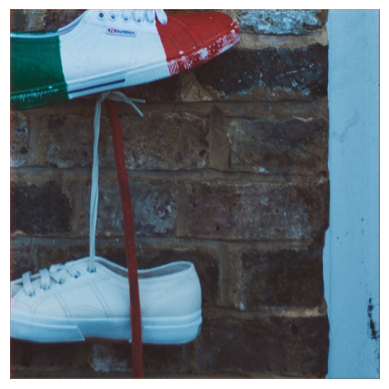

In [23]:

# plt.imshow(mask_noise)
plt.figure(1)
plt.imshow(sr_image_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0));
plt.axis('off')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

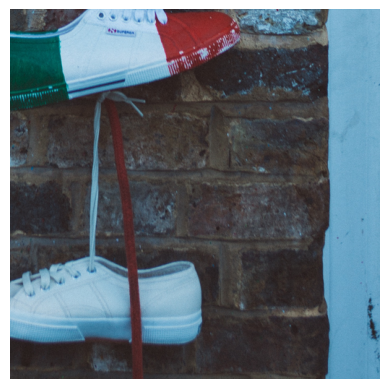

In [24]:

# plt.imshow(mask_noise)
plt.figure(1)
plt.imshow(ground_truth_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0));
plt.axis('off')
plt.show

In [25]:
lr_compression_result = eval_perf_compression(model_compression,input_tensor,None)
lr_compression_result

C:\Users\huyph\AppData\Local\Temp\ipykernel_34228\140740725.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(36.87736, dtype=float32),
 'Bpp': array(0.68519574, dtype=float32),
 'Bpp(fsize)': 0.5816650390625,
 'SSIM': array(0.03191948, dtype=float32),
 'PSNR_cmpref': None,
 'SSI_cmpref': None}

In [26]:
del model

In [27]:
# copied_model = copy.deepcopy(model)
# Download a pretrained NinaSR model for super 
model = ninasr_b0(scale=2, pretrained=True)
model = model.to(device)

In [28]:
# Generate superresolution from input_tensor
with torch.no_grad():
    sr_image_tensor_orig = model(input_tensor) # used as the reference 
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph


# Fine-Tune Settings
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers


for param in model_compression.parameters():
        param.requires_grad = False
        
# Define the maximum possible pixel value of the image
MAX_I = 1.

num_iterations = 1000

# Calculate the number of pixels
num_pixels = sr_image_tensor_orig.shape[0] * sr_image_tensor_orig.shape[2] * sr_image_tensor_orig.shape[3]
     

# scalingfactor = 2
# target_bpp = lr_compresion_result["Bpp"]/scalingfactor**2
target_bpp = 0.3



In [ ]:


def minbitrate_superresolution(input_tensor,  sr_image_tensor_orig, target_psnr,quality_loss_lambda,num_iterations, model_supres, model_compression,device=None,learningrate = 1e-3,Z_tensor = None, T_tensor = None):
    # ADMM for 
    '''
        min_n bpp(theta|n) 
        s.t   X = fsupres(x|theta)
              ||psnr(X, Ref_superresolion) - target_psnr || <= epsilon (1 dB)
              psnr(fdecompress(X), Ref_superresolion) >= target_psnr 
    '''
    # Anh Huy Phan 2024
    #
  
    # If no device is provided, use the device of the input tensor 'x'
    if device is None:
        device = input_tensor.device

    
    # # Initialize the noise pattern as a parameter
    # if initial_noise is None:
    #     noise_pattern = torch.nn.Parameter(errbound * torch.randn_like(x) * mask).to(device)
    # else:
    #     noise_pattern = torch.nn.Parameter(initial_noise * mask).to(device)

  
    if sr_image_tensor_orig is None:
        # Generate superresolution from input_tensor
        with torch.no_grad():
            sr_image_tensor_orig = model(input_tensor) # used as the reference 
        sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

    
    # Define the maximum possible pixel value of the image
    MAX_I = 1.0

    # Calculate the number of pixels
    num_pixels = sr_image_tensor_orig.shape[0] * sr_image_tensor_orig.shape[2] * sr_image_tensor_orig.shape[3]

    # Intialize parameters Z and dual T
    if Z_tensor is None:
        Z_tensor = copy.deepcopy(sr_image_tensor_orig)

    if T_tensor is None:
        T_tensor = torch.zeros_like(sr_image_tensor_orig)
    
    # Bound for MSE ||X - Ref_supref||_F <= delta 
    # computed from the bound PSNR

    delta_squared = sr_image_tensor_orig.shape[1]*num_pixels * (MAX_I ** 2) / (10 ** (target_psnr / 10))
    delta = torch.sqrt(torch.tensor(delta_squared))
    # print(delta)



    optimizer = torch.optim.Adam(model_supres.parameters(), lr=learningrate)
 
 
    outer_iterations = 50 # For ADMM 

    try:
        # Main algorithm 
       
        # quality_loss_lambda = 10
        # Define Loss and Optimizer
        loss_values = []  
        bpp_values = []
        psnr_values = []

        for ki in range(outer_iterations):

            # Train SR model to update X
            #  min bitrate(X) + \rho/2 ||X - Z - T||_F^2
            ZT = Z_tensor+T_tensor

            for iteration in range(num_iterations):
                optimizer.zero_grad()

                # Generate superresolution from input_tensor
                sr_image_tensor = model_supres(input_tensor)#.clamp(0, 1)

                # Forward pass through the model
                sr_compression = model_compression(sr_image_tensor)
                decompressed_sr_image = sr_compression['x_hat']#.clamp(0, 1)

                
                # Compute the bpp loss
                bpploss = bpp_loss(sr_compression, num_pixels)
            
                # MSE loss for compressed SR
                mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
                psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
                quality_loss_compressed_sr_vs_ref2 = (psnr_quality_compressed_sr_vs_ref - target_psnr)

                # MSE loss for SR
                mse_loss2 = F.mse_loss(sr_image_tensor, ZT)
                psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
                quality_loss_sr_vs_ref2 = (psnr_quality_sr_vs_ref - target_psnr)
            

                # Compute the bpp loss
                bpploss = bpp_loss(sr_compression, num_pixels)

                # Combine the losses
                combined_loss = (
                    10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * (quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
                    + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2.abs() + 1e-8)         
                )

            
                # Backward pass
                combined_loss.backward()
                optimizer.step()

                # Print the loss every 10 iterations
                if iteration % 10 == 0:
                    print(
                        f"Iteration {iteration} | PSNR Compressed SR vs Ref: {psnr_quality_compressed_sr_vs_ref:.2f} "
                        f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
                    )

                # Append the loss value
                loss_values.append(combined_loss.item())  
                bpp_values.append(bpploss.item())
                psnr_values.append(psnr_quality_sr_vs_ref.item())

            # end training superresolution model to update X

            # Update Z  
            D = sr_image_tensor - T_tensor
            E = D - sr_image_tensor_orig #+ torch.rand(Z_tensor.shape).to(device)*0.1
            normE= torch.linalg.norm(E.reshape(-1))
            # print(normE)
            if normE <= delta:
                Z_tensor = D.clone()
            else:
                Z_tensor = sr_image_tensor_orig + delta * E/normE


            # mse_loss = F.mse_loss(sr_image_tensor_orig, Z_tensor)
            # Z_psnr = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
            
            Z_tensor  = Z_tensor.detach()


            # Update dual T_tensor
            T_tensor = T_tensor + Z_tensor - sr_image_tensor
            T_tensor  = T_tensor.detach()

                  
    except KeyboardInterrupt:
        # Save checkpoint on interruption
        save_checkpoint({'Z_tensor': Z_tensor.data, \
                         'T_tensor': T_tensor.data,\
                         'Model_supres': model_supres,\
                         'loss_values': loss_values})
        print("Interrupted, checkpoint saved.")
        return model_supres, Z_tensor,T_tensor,loss_values_, bpp_values, psnr_values
    
    return model_supres, Z_tensor,T_tensor,loss_values,bpp_values, psnr_values


In [30]:
# # copied_model = copy.deepcopy(model)
# # Download a pretrained NinaSR model for super 
# model = ninasr_b0(scale=2, pretrained=True)
# model = model.to(device)

In [31]:
loss_values_ = []
bpp_values_ = []
psnr_values_ = []

In [32]:
# ADMM 
Z_tensor = copy.deepcopy(sr_image_tensor_orig)
T_tensor = torch.zeros_like(sr_image_tensor_orig)

quality_loss_lambda = 1
num_iterations = 100
target_psnr = 35



In [33]:
# model, Z_tensor,T_tensor,loss_values,bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
#                            quality_loss_lambda,num_iterations, model, model_compression,device=device,learningrate = 1e-4,Z_tensor=Z_tensor,T_tensor=T_tensor)



In [34]:

# # loss_values_,bpp_values_, psnr_values_ = loss_values,bpp_values, psnr_values
# loss_values_ = loss_values_ + loss_values
# bpp_values_ = bpp_values_ + bpp_values
# psnr_values_ = psnr_values_ + psnr_values

In [35]:
# # Generate superresolution from input_tensor
# with torch.no_grad():
#     sr_image_tensor = model(input_tensor)

# sr_compression_result_compress = eval_perf_compression(model_compression,sr_image_tensor,ground_truth_tensor)
# sr_compression_result_compress

 

Train the superresoliution model with different target psnr values

In [36]:
import copy
import torch

# Initialization
Z_tensor = copy.deepcopy(sr_image_tensor_orig)
T_tensor = torch.zeros_like(sr_image_tensor_orig)

quality_loss_lambda = 1
num_iterations = 100
initial_target_psnr = 36
psnr_reduction_step = 1  # Reduction in PSNR target per iteration
min_target_psnr = 32  # Minimum allowable target PSNR


filename_no_ext = filename[:-4]  # Remove the last 4 characters (e.g., '.png')


# Tracking performance per PSNR
performance_per_psnr = {}  # To store results for each target PSNR

# Main loop: Run until the target PSNR drops below the minimum allowed value
target_psnr = initial_target_psnr
 

In [37]:
while target_psnr >= min_target_psnr:
    print(f"Starting optimization for target PSNR: {target_psnr} dB")
    
    # Reset tracking metrics for the current target PSNR
    loss_values_ = []
    bpp_values_ = []
    psnr_values_ = []

    for krun in range(4):  # Inner loop for multiple ADMM iterations

        # Run the minbitrate_superresolution function
        model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(
            input_tensor,
            sr_image_tensor_orig,
            target_psnr,
            quality_loss_lambda,
            num_iterations,
            model,
            model_compression,
            device=device,
            learningrate=1e-4,
            Z_tensor=Z_tensor,
            T_tensor=T_tensor,
        )

        # Update the tracked metrics
        loss_values_ += loss_values
        bpp_values_ += bpp_values
        psnr_values_ += psnr_values
    
        # Check for stopping condition (e.g., convergence)
        if len(loss_values_) > 1 and abs(loss_values_[-1] - loss_values_[-2]) < 1e-4:
            print(f"Converged at target PSNR: {target_psnr} dB")
            break
    # end of for loop for a specific target_psnr

    # Get performance 
    # Generate superresolution from input_tensor
    with torch.no_grad():
        sr_image_tensor = model(input_tensor)
    # Evaluate performance
    sr_compression_result_compress = eval_perf_compression(model_compression,sr_image_tensor,ground_truth_tensor)
    sr_compression_result_compress 
    
    # Store current performance for the current target PSNR
    performance_per_psnr[target_psnr] = {
        "loss_values": loss_values_,
        "bpp_values": bpp_values_,
        "psnr_values": psnr_values_,
        "final_loss": loss_values_[-1] if loss_values_ else None,
        "final_bpp": bpp_values_[-1] if bpp_values_ else None,
        "final_psnr": psnr_values_[-1] if psnr_values_ else None,
        "bpp(fsize)": sr_compression_result_compress["Bpp(fsize)"],
        "bpp": sr_compression_result_compress["Bpp"],
        "ssim": sr_compression_result_compress["SSIM"],
        "psnr_comp_vs_ref": sr_compression_result_compress["PSNR_cmpref"],
        "ssim_comp_vs_ref": sr_compression_result_compress["SSI_cmpref"],
    }
 
    # Save model
    model_filename = f"sr_model_admm_div_{filename_no_ext}_psnr{target_psnr}.pth"
    print(f"Saving model state to: {model_filename}")
    torch.save(model.state_dict(), model_filename)

    # Save the entire model
    model_full_filename = f"sr_model_finetune_compression_admm_div_{filename_no_ext}_psnr{target_psnr}.pth"
    print(f"Saving full model to: {model_full_filename}")
    torch.save(model, model_full_filename)


    # Update the target PSNR for the next loop
    target_psnr -= psnr_reduction_step

print("\nOptimization process completed.")
print("Performance per PSNR:")
for psnr, metrics in performance_per_psnr.items():
    print(
        f"PSNR: {psnr} dB -> Final Loss: {metrics['final_loss']}, "
        f"Final BPP: {metrics['final_bpp']}, Final PSNR: {metrics['final_psnr']}, "
        f"BPP(fsize): {metrics['bpp(fsize)']}, SSIM: {metrics['ssim']}"
    )

Starting optimization for target PSNR: 36 dB
Iteration 0 | PSNR Compressed SR vs Ref: 39.28 | BPP: 0.5000 | Loss: 4.6661
Iteration 10 | PSNR Compressed SR vs Ref: 34.80 | BPP: 0.4785 | Loss: -1.8974
Iteration 20 | PSNR Compressed SR vs Ref: 36.19 | BPP: 0.4623 | Loss: -2.8323
Iteration 30 | PSNR Compressed SR vs Ref: 36.20 | BPP: 0.4543 | Loss: -2.9661
Iteration 40 | PSNR Compressed SR vs Ref: 35.89 | BPP: 0.4436 | Loss: -3.3094
Iteration 50 | PSNR Compressed SR vs Ref: 35.95 | BPP: 0.4387 | Loss: -3.4753
Iteration 60 | PSNR Compressed SR vs Ref: 35.90 | BPP: 0.4298 | Loss: -3.5605
Iteration 70 | PSNR Compressed SR vs Ref: 35.92 | BPP: 0.4233 | Loss: -3.6209
Iteration 80 | PSNR Compressed SR vs Ref: 35.94 | BPP: 0.4141 | Loss: -3.7622
Iteration 90 | PSNR Compressed SR vs Ref: 35.93 | BPP: 0.4073 | Loss: -3.8071
Iteration 0 | PSNR Compressed SR vs Ref: 35.93 | BPP: 0.4015 | Loss: -0.9524
Iteration 10 | PSNR Compressed SR vs Ref: 35.56 | BPP: 0.4192 | Loss: -2.9679
Iteration 20 | PSNR Co

C:\Users\huyph\AppData\Local\Temp\ipykernel_34228\140740725.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


Saving model state to: sr_model_admm_div_0025_psnr36.pth
Saving full model to: sr_model_finetune_compression_admm_div_0025_psnr36.pth
Starting optimization for target PSNR: 35 dB
Iteration 0 | PSNR Compressed SR vs Ref: 36.01 | BPP: 0.3382 | Loss: -3.5905
Iteration 10 | PSNR Compressed SR vs Ref: 35.05 | BPP: 0.3183 | Loss: -4.8911
Iteration 20 | PSNR Compressed SR vs Ref: 35.01 | BPP: 0.3161 | Loss: -4.9791
Iteration 30 | PSNR Compressed SR vs Ref: 34.98 | BPP: 0.3159 | Loss: -4.9840
Iteration 40 | PSNR Compressed SR vs Ref: 35.00 | BPP: 0.3148 | Loss: -5.0167
Iteration 50 | PSNR Compressed SR vs Ref: 35.02 | BPP: 0.3149 | Loss: -4.9939
Iteration 60 | PSNR Compressed SR vs Ref: 35.06 | BPP: 0.3147 | Loss: -4.9492
Iteration 70 | PSNR Compressed SR vs Ref: 35.02 | BPP: 0.3136 | Loss: -5.0096
Iteration 80 | PSNR Compressed SR vs Ref: 34.98 | BPP: 0.3125 | Loss: -5.0287
Iteration 90 | PSNR Compressed SR vs Ref: 35.04 | BPP: 0.3139 | Loss: -4.9891
Iteration 0 | PSNR Compressed SR vs Ref: 3

In [ ]:
print("\nOptimization process completed.")
print("Performance per PSNR:")
for psnr, metrics in performance_per_psnr.items():
    print(
        f"PSNR: {psnr} dB -> Final Loss: {metrics['final_loss']}, "
        f"Final BPP: {metrics['final_bpp']}, Final PSNR: {metrics['psnr_comp_vs_ref']}, "
        f"BPP(fsize): {metrics['bpp(fsize)']}, SSIM: {metrics['ssim']}"
    )


Optimization process completed.
Performance per PSNR:
PSNR: 36 dB -> Final Loss: -3.545091390609741, Final BPP: 0.44090503454208374, Final PSNR: 30.947860717773438, BPP(fsize): 0.329864501953125, SSIM: 0.03353317081928253
PSNR: 35 dB -> Final Loss: -3.960292339324951, Final BPP: 0.3986615538597107, Final PSNR: 30.71965217590332, BPP(fsize): 0.286773681640625, SSIM: 0.03184908255934715
PSNR: 34 dB -> Final Loss: -4.324019908905029, Final BPP: 0.3674280643463135, Final PSNR: 30.395606994628906, BPP(fsize): 0.256866455078125, SSIM: 0.030329672619700432
PSNR: 33 dB -> Final Loss: -4.647892475128174, Final BPP: 0.34216275811195374, Final PSNR: 29.926597595214844, BPP(fsize): 0.230133056640625, SSIM: 0.028606299310922623
PSNR: 32 dB -> Final Loss: -4.9797258377075195, Final BPP: 0.31701985001564026, Final PSNR: 29.553606033325195, BPP(fsize): 0.206451416015625, SSIM: 0.03002774342894554


In [ ]:
baseline_sr_results

[{'PSNR': array(36.507786, dtype=float32),
  'Bpp': array(0.6754012, dtype=float32),
  'Bpp(fsize)': 0.559356689453125,
  'SSIM': array(0.0324214, dtype=float32),
  'PSNR_cmpref': array(32.67857, dtype=float32),
  'SSI_cmpref': array(0.07819959, dtype=float32)},
 {'PSNR': array(41.293823, dtype=float32),
  'Bpp': array(0.44460464, dtype=float32),
  'Bpp(fsize)': 0.331939697265625,
  'SSIM': array(0.01179014, dtype=float32),
  'PSNR_cmpref': array(32.96242, dtype=float32),
  'SSI_cmpref': array(0.08091034, dtype=float32)},
 {'PSNR': array(39.911263, dtype=float32),
  'Bpp': array(0.4945737, dtype=float32),
  'Bpp(fsize)': 0.381988525390625,
  'SSIM': array(0.01605576, dtype=float32),
  'PSNR_cmpref': array(33.49774, dtype=float32),
  'SSI_cmpref': array(0.07421972, dtype=float32)}]

In [ ]:
# Backup the original comparison_table
backup_comparison_table = comparison_table.copy()


In [ ]:
comparison_table = backup_comparison_table.copy()

# Extend the comparison_table with performance_per_psnr data
for target_psnr, results in performance_per_psnr.items():
    row = {
        "Method": f"Optimized NinaSR (PSNR {target_psnr})",
        "PSNR": results.get("final_psnr", None),
        "Bpp": results.get("bpp", None),
        "Bpp(fsize)": results.get("bpp(fsize)", None),
        "SSIM": results.get("ssim", None),
        "PSNR_cmpref": results.get("psnr_comp_vs_ref", None),
        "SSI_cmpref": results.get("ssim_comp_vs_ref", None),
    }
    comparison_table = pd.concat([comparison_table, pd.DataFrame([row])], ignore_index=True)

print(comparison_table)


                       Method       PSNR         Bpp  Bpp(fsize)         SSIM  \
0            Nearest Neighbor  36.507786   0.6754012    0.559357  0.032421395   
1                    Bilinear  41.293823  0.44460464    0.331940  0.011790141   
2                     Bicubic  39.911263   0.4945737    0.381989  0.016055759   
3                      NinaSR   37.62241   0.5944497    0.487335  0.024821935   
4  Optimized NinaSR (PSNR 36)  36.024513  0.44173813    0.329865   0.03353317   
5  Optimized NinaSR (PSNR 35)  35.007778   0.3984282    0.286774  0.031849083   
6  Optimized NinaSR (PSNR 34)  34.051914   0.3683098    0.256866  0.030329673   
7  Optimized NinaSR (PSNR 33)  33.058933  0.34076488    0.230133    0.0286063   
8  Optimized NinaSR (PSNR 32)  32.009216  0.31870916    0.206451  0.030027743   

  PSNR_cmpref   SSI_cmpref  
0    32.67857   0.07819959  
1    32.96242   0.08091034  
2    33.49774   0.07421972  
3    31.22659  0.078679465  
4    30.94786   0.09093531  
5   30.719652  

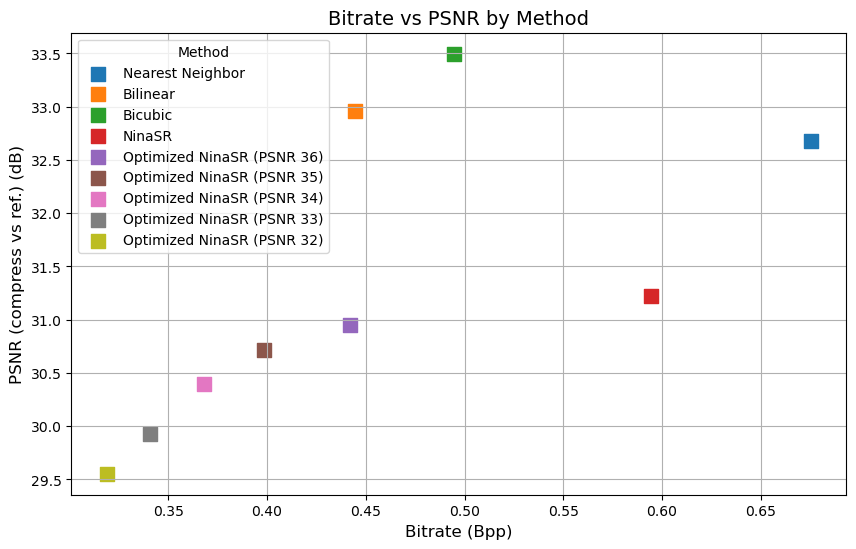

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))
for i, row in comparison_table.iterrows():
    plt.scatter(row["Bpp"], row["PSNR_cmpref"], label=row["Method"], s=100,marker = 's')
 
# for psnr, metrics in performance_per_psnr.items():
#     plt.scatter(metrics['final_bpp'], metrics['psnr_comp_vs_ref'], label=f"Optimized NinaSR {psnr}dB", s=100)


plt.title("Bitrate vs PSNR by Method", fontsize=14)
plt.xlabel("Bitrate (Bpp)", fontsize=12)
plt.ylabel("PSNR (compress vs ref.) (dB)", fontsize=12)
plt.legend(title="Method", fontsize=10)
plt.grid(True)
plt.show()

In [ ]:
import pickle
# Create a file object in write and binary mode

# Save the entire model
filename = f"sr_model_finetune_compression_admm_div_{filename_no_ext}_finalresults.pkl"


with open (filename, 'wb') as f:
    # Store the list object to the file using the dump method
    data  = { 'comparison_table ' : comparison_table, 'performance_per_psnr'  : performance_per_psnr,  'baseline_sr_results' :  baseline_sr_results}
    pickle.dump(data,f,pickle.HIGHEST_PROTOCOL)

#kodakidx = 24


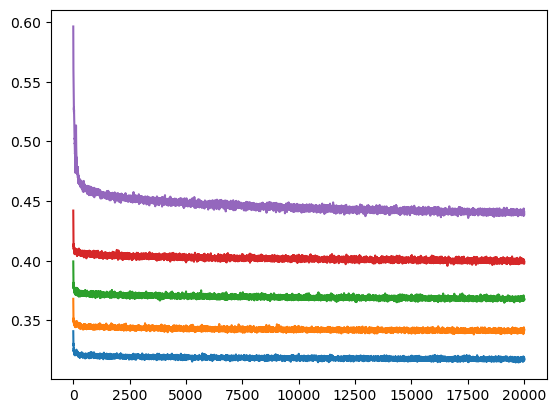

In [ ]:
plt.plot(performance_per_psnr[32]["bpp_values"]);
plt.plot(performance_per_psnr[33]["bpp_values"]);
plt.plot(performance_per_psnr[34]["bpp_values"]);
plt.plot(performance_per_psnr[35]["bpp_values"]);
plt.plot(performance_per_psnr[36]["bpp_values"]);

In [39]:
loss_values_

[-4.733682155609131,
 -4.907532691955566,
 -5.11177921295166,
 -5.299871921539307,
 -5.545337200164795,
 -5.81324577331543,
 -5.851552486419678,
 -5.800382137298584,
 -5.881884574890137,
 -5.96038293838501,
 -6.041525363922119,
 -6.013994216918945,
 -6.027251243591309,
 -5.973191261291504,
 -6.000077247619629,
 -6.0446696281433105,
 -6.057559013366699,
 -6.0516862869262695,
 -6.066256523132324,
 -6.103653907775879,
 -6.078253746032715,
 -6.077746868133545,
 -6.089730262756348,
 -6.113243103027344,
 -6.102440357208252,
 -6.105659008026123,
 -6.091527462005615,
 -6.097440719604492,
 -6.077347278594971,
 -6.097511291503906,
 -6.109828472137451,
 -6.0871663093566895,
 -6.106541633605957,
 -6.075123310089111,
 -6.139498233795166,
 -6.133205413818359,
 -6.08986234664917,
 -6.096309661865234,
 -6.0904035568237305,
 -6.101041316986084,
 -6.145934104919434,
 -6.0638813972473145,
 -6.058320999145508,
 -6.0751495361328125,
 -6.0617828369140625,
 -6.148814678192139,
 -6.161471843719482,
 -6.095123

In [42]:
# Parameters
window_size = 100  # Number of recent loss values to consider
variance_threshold = 1e-3  # Threshold for variance to consider stable

# Assuming `loss_values` is a list storing the loss values
if len(loss_values_) >= window_size:
    recent_losses = loss_values_[-window_size:]  # Get the last `window_size` loss values
    variance = np.var(recent_losses)  # Compute the variance
    
    if variance < variance_threshold:
        print("Loss values have stabilized. Stopping the update.")
        stop_training = True  # A flag to indicate stopping (to be used in your training loop)
    else:
        stop_training = False
else:
    stop_training = False  # Not enough values to compute the variance yet 

print(variance)
print(stop_training)

Loss values have stabilized. Stopping the update.
0.000233304002555451
True


In [ ]:
# filename_no_ext = filename[:-4]  # Remove the last 4 characters (e.g., '.png')

# # Save state dictionary (recommended)
# modelfname = f"sr_model_admm_div_{filename_no_ext}.pth"
# torch.save(model.state_dict(), modelfname)

# # # Save the entire model``
# modelfname = f"sr_model_finetune_compression_admm_div_{filename_no_ext}.pth"
# torch.save(model, modelfname)

In [ ]:
# model = torch.load(modelfname)

In [ ]:
# # Scatter plot
# plt.figure(figsize=(10, 6))
# for i, row in comparison_table.iterrows():
#     plt.scatter(row["Bpp"], row["PSNR_cmpref"], label=row["Method"], s=100)

# plt.title("Bitrate vs PSNR by Method", fontsize=14)
# plt.xlabel("Bitrate (Bpp)", fontsize=12)
# plt.ylabel("PSNR (compress vs ref.) (dB)", fontsize=12)
# plt.legend(title="Method", fontsize=10)
# plt.grid(True)
# plt.show()

In [ ]:
# END OF THE FILE

In [ ]:
# quality_loss_lambda = 10
# # Define Loss and Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# target_psnr = 35


In [ ]:
# num_iterations = 100000

# for iteration in range(num_iterations):
#     optimizer.zero_grad()

#     # Generate superresolution from input_tensor
#     sr_image_tensor = model(input_tensor)#.clamp(0, 1)

#     # Forward pass through the model
#     sr_compression = model_compression(sr_image_tensor)
#     decompressed_sr_image = sr_compression['x_hat']#.clamp(0, 1)

#     # MSE loss for compressed SR
#     mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
#     psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
#     quality_loss_compressed_sr_vs_ref2 = (psnr_quality_compressed_sr_vs_ref - target_psnr)

#     # MSE loss for SR
#     mse_loss2 = F.mse_loss(sr_image_tensor, sr_image_tensor_orig)
#     psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
#     quality_loss_sr_vs_ref2 = (psnr_quality_sr_vs_ref - target_psnr)

#     # Compute the bpp loss
#     bpploss = bpp_loss(sr_compression, num_pixels)

#     # Combine the losses
#     combined_loss = (
#         10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda/10 * (quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#         + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     # )

#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) #+ quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8)  #+ quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda/(iteration/1+1) * torch.log10(torch.max(torch.tensor(1e-8),psnr_quality_sr_vs_ref-(target_psnr-5)))        
#     # )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)
#     # )

#     # Backward pass
#     combined_loss.backward()
#     optimizer.step()

#     # Print the loss every 10 iterations
#     if iteration % 10 == 0:
#         # print(
#         #     f"Iteration {iteration} "
#         #     f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         # )
#         print(
#             f"Iteration {iteration} | PSNR Compressed SR vs Ref: {psnr_quality_compressed_sr_vs_ref:.2f} "
#             f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         )


In [ ]:
# num_iterations = 100000

# for iteration in range(num_iterations):
#     optimizer.zero_grad()

#     # Generate superresolution from input_tensor
#     sr_image_tensor = model(input_tensor)#.clamp(0, 1)

#     # Forward pass through the model
#     sr_compression = model_compression(sr_image_tensor)
#     decompressed_sr_image = sr_compression['x_hat']#.clamp(0, 1)

#     # MSE loss for compressed SR
#     mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
#     psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
#     quality_loss_compressed_sr_vs_ref2 = (psnr_quality_compressed_sr_vs_ref - target_psnr)

#     # MSE loss for SR
#     mse_loss2 = F.mse_loss(sr_image_tensor, sr_image_tensor_orig)
#     psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
#     quality_loss_sr_vs_ref2 = (psnr_quality_sr_vs_ref - target_psnr)

#     # Compute the bpp loss
#     bpploss = bpp_loss(sr_compression, num_pixels)

#     # Combine the losses
#     combined_loss = (
#         10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda/10 * (quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#         + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     # )

#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) #+ quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8)  #+ quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda/(iteration/1+1) * torch.log10(torch.max(torch.tensor(1e-8),psnr_quality_sr_vs_ref-(target_psnr-5)))        
#     # )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)
#     # )

#     # Backward pass
#     combined_loss.backward()
#     optimizer.step()

#     # Print the loss every 10 iterations
#     if iteration % 10 == 0:
#         # print(
#         #     f"Iteration {iteration} "
#         #     f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         # )
#         print(
#             f"Iteration {iteration} | PSNR Compressed SR vs Ref: {psnr_quality_compressed_sr_vs_ref:.2f} "
#             f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         )


In [ ]:
# num_iterations = 100000

# for iteration in range(num_iterations):
#     optimizer.zero_grad()

#     # Generate superresolution from input_tensor
#     sr_image_tensor = model(input_tensor)#.clamp(0, 1)

#     # Forward pass through the model
#     sr_compression = model_compression(sr_image_tensor)
#     decompressed_sr_image = sr_compression['x_hat']#.clamp(0, 1)

#     # MSE loss for compressed SR
#     mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
#     psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
#     quality_loss_compressed_sr_vs_ref2 = (psnr_quality_compressed_sr_vs_ref - target_psnr)

#     # MSE loss for SR
#     mse_loss2 = F.mse_loss(sr_image_tensor, sr_image_tensor_orig)
#     psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
#     quality_loss_sr_vs_ref2 = (psnr_quality_sr_vs_ref - target_psnr)

#     # Compute the bpp loss
#     bpploss = bpp_loss(sr_compression, num_pixels)

#     # Combine the losses
#     combined_loss = (
#         10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda/10 * (quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#         + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)         
#     # )

#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) #+ quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8)  #+ quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda/(iteration/1+1) * torch.log10(torch.max(torch.tensor(1e-8),psnr_quality_sr_vs_ref-(target_psnr-5)))        
#     # )

#     # # Combine the losses
#     # combined_loss = (
#     #     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * torch.log10(quality_loss_compressed_sr_vs_ref2.abs() + 1e-8) 
#     #     + quality_loss_lambda * torch.log10(quality_loss_sr_vs_ref2.abs() + 1e-8)
#     # )

#     # Backward pass
#     combined_loss.backward()
#     optimizer.step()

#     # Print the loss every 10 iterations
#     if iteration % 10 == 0:
#         # print(
#         #     f"Iteration {iteration} "
#         #     f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         # )
#         print(
#             f"Iteration {iteration} | PSNR Compressed SR vs Ref: {psnr_quality_compressed_sr_vs_ref:.2f} "
#             f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
#         )


In [ ]:
# # Save state dictionary (recommended)
# torch.save(model.state_dict(), "sr_model.pth")

# # Save the entire model``
# torch.save(model, "sr_model_finetune_compression.pth")

In [ ]:
# # Generate superresolution from input_tensor
# with torch.no_grad():
#     sr_image_tensor = model(input_tensor)

# sr_compression_result_final = eval_perf_compression(model_compression,sr_image_tensor)
# sr_compression_result_final

# # MSE loss for SR
# mse_loss2 = F.mse_loss(sr_image_tensor, sr_image_tensor_orig)
# psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
# sr_compression_result_final["PSNR"] = psnr_quality_sr_vs_ref.to('cpu')
# sr_compression_result_final

In [ ]:
# psnr_quality_sr_vs_ref

In [ ]:
# # Combine the data into a DataFrame
# data = {
#     "Metric": ["PSNR", "Bpp", "Bpp(fsize)", "SSIM"],
#     "SR Compression (Initial)": [
#         sr_compression_result['PSNR'],
#         sr_compression_result['Bpp'],
#         sr_compression_result['Bpp(fsize)'],
#         sr_compression_result['SSIM']
#     ],
#     "LR Compression (Initial)": [
#         lr_compression_result['PSNR'],
#         lr_compression_result['Bpp'],
#         lr_compression_result['Bpp(fsize)'],
#         lr_compression_result['SSIM']
#     ],
#     "SR Compression (Final)": [
#         sr_compression_result_final['PSNR'],
#         sr_compression_result_final['Bpp'],
#         sr_compression_result_final['Bpp(fsize)'],
#         sr_compression_result_final['SSIM']
#     ]
# }

# # Create a DataFrame
# df = pd.DataFrame(data)

# # Print the table
# print(df)

In [ ]:
# sr = to_pil_image(sr_image_tensor.clamp(0,1).squeeze(0))
# sr.show()

In [ ]:

# # plt.imshow(mask_noise)
# plt.figure(1)
# plt.imshow(sr_image_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0));
# plt.axis('off')
# plt.show

In [ ]:
# # Generate superresolution from input_tensor
# sr_image_tensor = model(input_tensor)
# sr_image_tensor.shape

# # Forward pass through the model
# output_compression = model_compression(sr_image_tensor)


# # Compute bpp loss (to be maximized, hence the negative sign)
# baseline_bpp = (torch.log(output_compression['likelihoods']['y']).sum() + \
#     torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)



In [ ]:

# # Define the maximum possible pixel value of the image
# MAX_I = 1.0


# # Fine-Tune Settings
# for param in model.parameters():
#     param.requires_grad = True  # Unfreeze all layers

# # Define Loss and Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# # Training Loop (Simplified)
# for epoch in range(num_epochs):
#     for lr_images, hr_images in dataloader:
        

#         # Generate superresolution from input_tensor
#         sr_image_tensor = model(lr_images)

#         # Forward pass through the model
#         output_compression = model_compression(sr_image_tensor)
        

#         # Check the bitrate of compressed file for the superresolution image : sr_image_tensor
#         # Compress the super resolution image 
#         x = sr_image_tensor

#         num_pixels = x.shape[2]*x.shape[3]
#         # model and net are the same , but net is on cpu and for compression 

#         mse_loss_original = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), x)
#         target_psnr = 10 * torch.log10((MAX_I ** 2) / mse_loss_original)


#         target_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), x)


#         # TOTAL loss = min of bitrate and max target_psnr


#         # Assuming 'output' is a dictionary with key 'x_hat' for the reconstructed image
#         output_compression_image = output_compression['x_hat']

#         mse_loss = F.mse_loss(output_compression, x)

#         # Calculate PSNR loss
#         psnr_quality = 10 * torch.log10((MAX_I ** 2) / mse_loss)

#         # Compute the difference in PSNR between perturbed and target
#         quality_loss = (psnr_quality).abs()


#         # Compute the bpp loss
#         bpploss = (torch.log(output_compression['likelihoods']['y']).sum() + \
#             torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)


#         quality_loss_lambda = 0.01
#         combined_loss = 10*torch.log10(bpploss) - quality_loss_lambda * torch.log10(quality_loss) 


#         # Perform gradient descent 

#         optimizer.zero_grad()
#         combined_loss.backward()
#         optimizer.step()


#         print(f"Epoch {epoch}, Loss: {loss.item()}")